# Matrix Plots

---

### Table of Contents
1. Introduction
2. Heatmaps (`sns.heatmap`)
3. Heatmap of a Correlation Matrix
4. Clustermaps (`sns.clustermap`)

---

## 1. Introduction
- Matrix plots are used to visualize 2D, matrix-like data where individual
  values are represented by color.
- Their primary use cases are for visualizing correlation matrices and showing
  patterns in data over two variables (e.g., time vs. categories).
- We will cover `sns.heatmap` and the more advanced `sns.clustermap`.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Apply a theme
sns.set_theme(style="white")


---

## 2. Heatmaps (`sns.heatmap`)
- The most common tool for visualizing a grid of data.
- To create a heatmap, the data often needs to be in a 2D matrix format,
  where both the rows and the columns have meaningful labels. A pivot table is
  a perfect way to prepare data for this.

Flights data pivoted into a Year x Month matrix:
 year    1949   1950   1951   1952   1953   1954   1955   1956   1957   1958  \
month                                                                         
Jan    112.0  115.0  145.0  171.0  196.0  204.0  242.0  284.0  315.0  340.0   
Feb    118.0  126.0  150.0  180.0  196.0  188.0  233.0  277.0  301.0  318.0   
Mar    132.0  141.0  178.0  193.0  236.0  235.0  267.0  317.0  356.0  362.0   
Apr    129.0  135.0  163.0  181.0  235.0  227.0  269.0  313.0  348.0  348.0   
May    121.0  125.0  172.0  183.0  229.0  234.0  270.0  318.0  355.0  363.0   

year    1959   1960  
month                
Jan    360.0  417.0  
Feb    342.0  391.0  
Mar    406.0  419.0  
Apr    396.0  461.0  
May    420.0  472.0  


/var/folders/3d/fs3qmksj2_ndtbx3blcmtwzr0000gn/T/ipykernel_91387/2975365636.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights_pivot = flights_df.pivot_table(


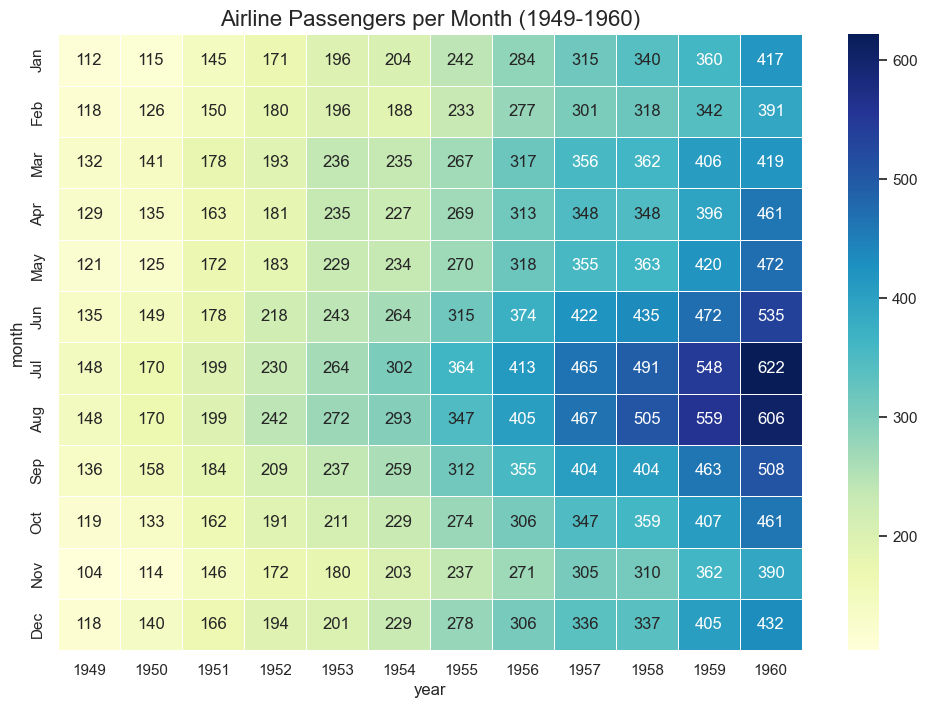

In [2]:
# Load the 'flights' dataset
flights_df = sns.load_dataset("flights")

# Use Pandas' `.pivot_table()` to create a matrix
flights_pivot = flights_df.pivot_table(
    index="month", columns="year", values="passengers"
)
print("Flights data pivoted into a Year x Month matrix:\n", flights_pivot.head())

# Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    data=flights_pivot,
    annot=True,  # Display the data value in each cell
    fmt=".0f",  # Format the annotations as floats with no decimals,
    cmap="YlGnBu",  # Specify the color map (Yellow-Green-Blue in this case)
    linewidths=0.5,  # Add lines between cells
)
plt.title("Airline Passengers per Month (1949-1960)", fontsize=16)
plt.show()


---

## 3. Heatmap of a Correlation Matrix
- One of the most frequent use cases for a heatmap is to visualize the
  correlation between many numerical variables in a dataset.

In [4]:
# Load the 'penguins' dataset
penguins_df = sns.load_dataset("penguins")

# Select only numerical columns for correlation calculation
# In modern Pandas, this can be done directly
numerical_cols = penguins_df.select_dtypes(include=np.number)

# Calculate the correlation matrix using Pandas' `.corr()`
correlation_matrix = numerical_cols.corr()
print("Correlation matrix of penguin measurements:\n", correlation_matrix)

Correlation matrix of penguin measurements:
                    bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.235053           0.656181   
bill_depth_mm           -0.235053       1.000000          -0.583851   
flipper_length_mm        0.656181      -0.583851           1.000000   
body_mass_g              0.595110      -0.471916           0.871202   

                   body_mass_g  
bill_length_mm        0.595110  
bill_depth_mm        -0.471916  
flipper_length_mm     0.871202  
body_mass_g           1.000000  


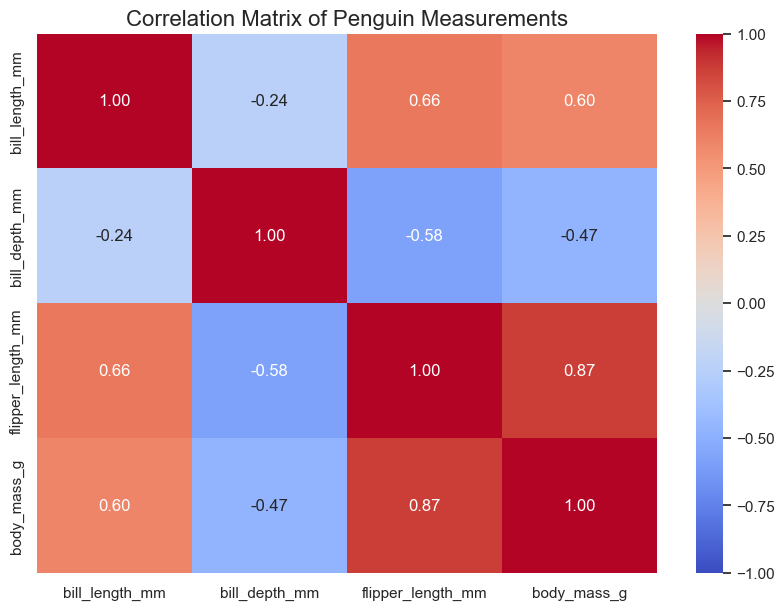

In [5]:
# Create the Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    data=correlation_matrix,
    annot=True,
    fmt=".2f",  # Format annotations to 2 decimal places
    cmap="coolwarm",  # Use a diverging colormap for correlations
    vmin=-1,
    vmax=1,  # Set the color bar limits from -1 to 1
)
plt.title("Correlation Matrix of Penguin Measurements", fontsize=16)
plt.show()


---

## 4. Clustermaps (`sns.clustermap`)
- A clustermap is a more advanced heatmap. It uses hierarchical clustering
  to reorder the rows and columns, placing similar rows and columns together.
- This can automatically reveal patterns and subgroups in your data.
- It returns a `ClusterGrid` object, not a standard Axes.

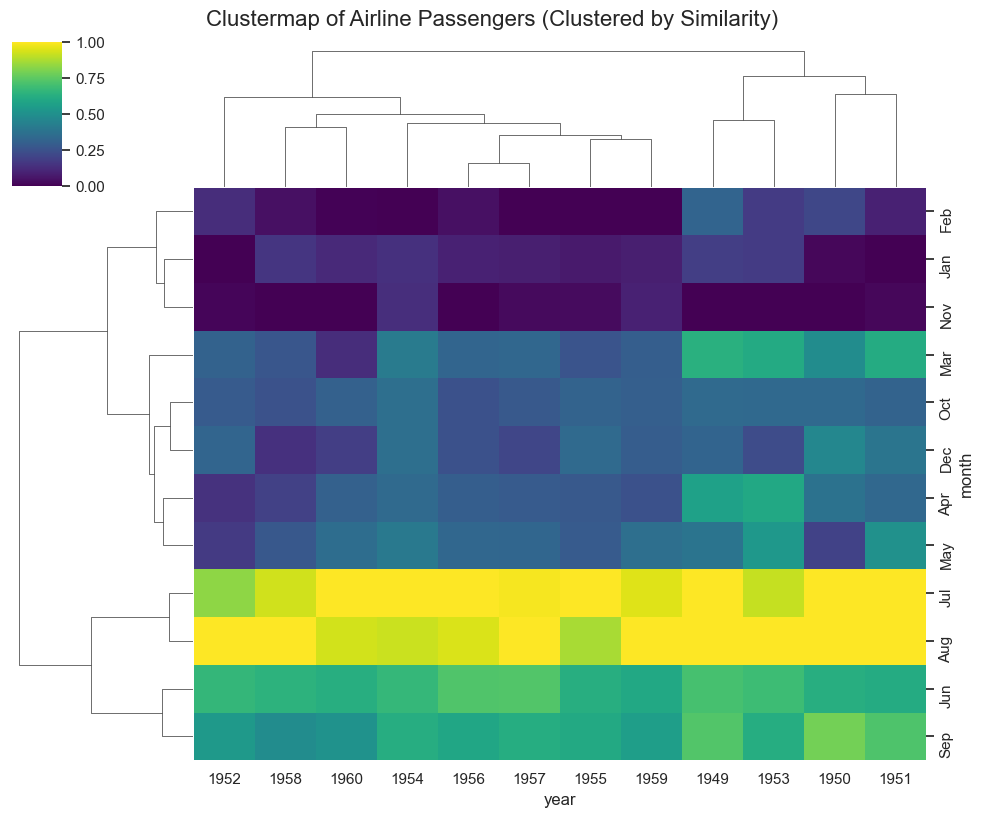

In [6]:
# `sns.clustermap` creates its own figure.
# `standard_scale=1` normalizes the data within the columns, making patterns more visible.
g = sns.clustermap(flights_pivot, cmap="viridis", standard_scale=1, figsize=(10, 8))
g.figure.suptitle(
    "Clustermap of Airline Passengers (Clustered by Similarity)", y=1.02, fontsize=16
)
plt.show()


---

**Next:** [Multi Plot Grids](./05_multi_plot_grids.ipynb)